# Objective

- **A Behavioral Intelligence Model for Early Churn Detection**

*- *Use behavioral + drift features to predict churn BEFORE it happens**

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset/processed/credit_card_clean.csv")

# Target Variable

In [4]:
df["Churn"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})
print(df["Churn"].value_counts())

Churn
0    8500
1    1627
Name: count, dtype: int64


In [5]:
# =============================
# FEATURE ENGINEERING (REBUILD)
# =============================

# Core Features
df["Transaction_Velocity"] = df["Total_Trans_Ct"] / 12
df["Engagement"] = df["Total_Trans_Ct"] / df["Months_on_book"]

# Drift Features
df["Expected_Transactions"] = df["Total_Trans_Ct"] / df["Months_on_book"]
df["Recent_Transactions"] = df["Total_Trans_Ct"] / 12
df["Transaction_Drift"] = df["Recent_Transactions"] - df["Expected_Transactions"]

df["Expected_Spend"] = df["Total_Trans_Amt"] / df["Months_on_book"]
df["Recent_Spend"] = df["Total_Trans_Amt"] / 12
df["Spend_Drift"] = df["Recent_Spend"] - df["Expected_Spend"]

df["Engagement_Drift"] = df["Transaction_Drift"]  # same logic proxy

df["Inactivity_Risk"] = df["Months_Inactive_12_mon"] / 12

df["Behavioral_Risk_Score"] = (
    -df["Transaction_Drift"] * 0.4 +
    -df["Spend_Drift"] * 0.3 +
    df["Inactivity_Risk"] * 0.3
)

# Handle division issues
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# FEATURE SELECTION

**Core Behavioral Features**

In [6]:
behavior_features = [
    "Transaction_Velocity",
    "Engagement",
    "Avg_Utilization_Ratio",
    "Months_Inactive_12_mon"
]

**Drift Features**

In [7]:
drift_features = [
    "Transaction_Drift",
    "Spend_Drift",
    "Engagement_Drift",
    "Behavioral_Risk_Score"
]

**Combining both**

In [8]:
features = behavior_features + drift_features
X = df[features]
y = df["Churn"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL 1 — Logistic Regression

In [11]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# MODEL 2 — Random Forest

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# Evaluation Function

In [13]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n🔹 {model_name}")
    
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [14]:
evaluate_model(y_test, y_pred_log, y_prob_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")


🔹 Logistic Regression
Accuracy: 0.8440276406712734
Precision: 0.5319148936170213
Recall: 0.23076923076923078
F1 Score: 0.3218884120171674
ROC-AUC: 0.8607714918826029

Confusion Matrix:
[[1635   66]
 [ 250   75]]

🔹 Random Forest
Accuracy: 0.9151036525172754
Precision: 0.8731707317073171
Recall: 0.5507692307692308
F1 Score: 0.6754716981132075
ROC-AUC: 0.9560113960113961

Confusion Matrix:
[[1675   26]
 [ 146  179]]


# Feature Importance

**Logistic Coefficients**

In [15]:
coeff_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coeff_df

,Feature,Coefficient
5,Spend_Drift,0.643585
3,Months_Inactive_12_mon,0.525197
1,Engagement,-0.345544
7,Behavioral_Risk_Score,-0.631103
2,Avg_Utilization_Ratio,-0.655057
0,Transaction_Velocity,-0.667891
4,Transaction_Drift,-0.719164
6,Engagement_Drift,-0.719164


**Random Forest Importance**

In [16]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
2,Avg_Utilization_Ratio,0.181488
0,Transaction_Velocity,0.175274
5,Spend_Drift,0.168882
7,Behavioral_Risk_Score,0.133831
1,Engagement,0.121331
4,Transaction_Drift,0.101364
6,Engagement_Drift,0.085555
3,Months_Inactive_12_mon,0.032274


# Visualization

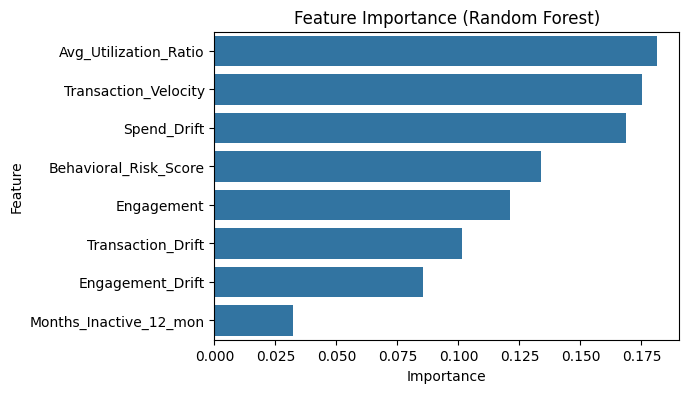

In [17]:
plt.figure(figsize=(6,4))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance (Random Forest)")
plt.show()

**ROC Curve**

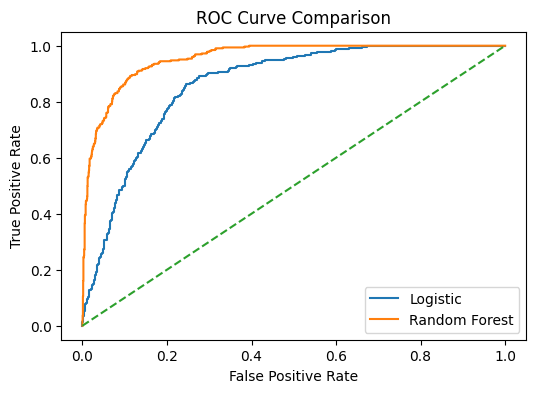

In [18]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,4))
plt.plot(fpr_log, tpr_log, label="Logistic")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

**Threshold Tuning**

- Lower threshold → catch churn EARLY (higher recall)

In [19]:
threshold = 0.3

y_pred_custom = (y_prob_rf >= threshold).astype(int)

evaluate_model(y_test, y_pred_custom, y_prob_rf, "RF (Threshold = 0.3)")


🔹 RF (Threshold = 0.3)
Accuracy: 0.9081934846989141
Precision: 0.6853333333333333
Recall: 0.7907692307692308
F1 Score: 0.7342857142857143
ROC-AUC: 0.9560113960113961

Confusion Matrix:
[[1583  118]
 [  68  257]]


# Why SHAP?

- **Our Model Predicts Churn and SHAP(SHapely Additive exPlanation) helps to answers "WHY did the model predict churn?"**
- **This helps in transformation of analytical model to Decision Intelligence System**

In [34]:
import shap
shap.initjs()

**Using TreeExplainer for Random Forest**

In [21]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

In [22]:
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]   # churn class
else:
    shap_to_plot = shap_values

In [23]:
print(type(shap_values))
print(np.array(shap_to_plot).shape)
print(X_test.shape)

<class 'numpy.ndarray'>
(2026, 8, 2)
(2026, 8)


In [29]:
shap_to_plot = shap_values[:, :, 1]

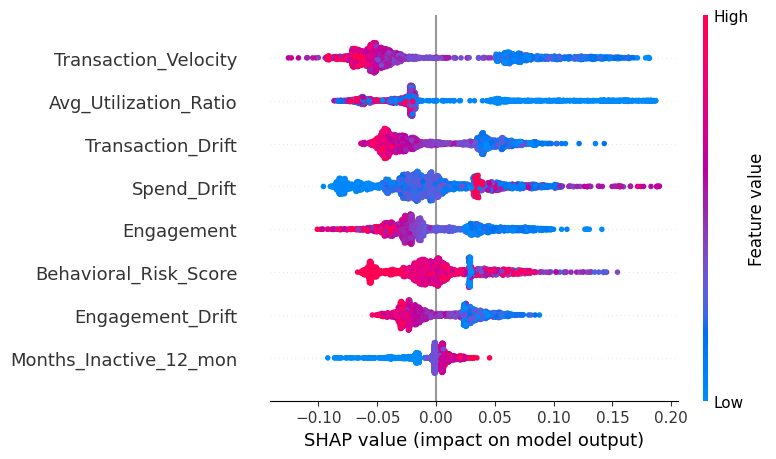

In [30]:
shap.summary_plot(shap_to_plot, X_test)

# Bar Plot

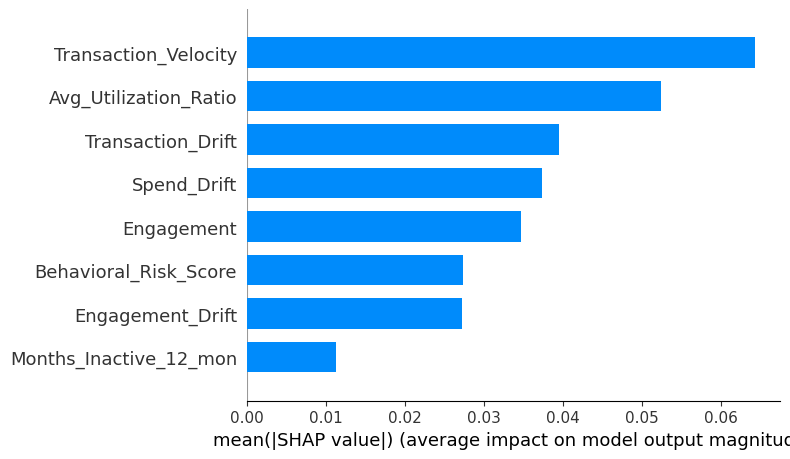

In [31]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_to_plot,
    X_test,
    plot_type="bar",
    max_display=10
)

plt.show()

# Individual Prediction Explanation

In [27]:
print(np.array(shap_values).shape)

(2026, 8, 2)


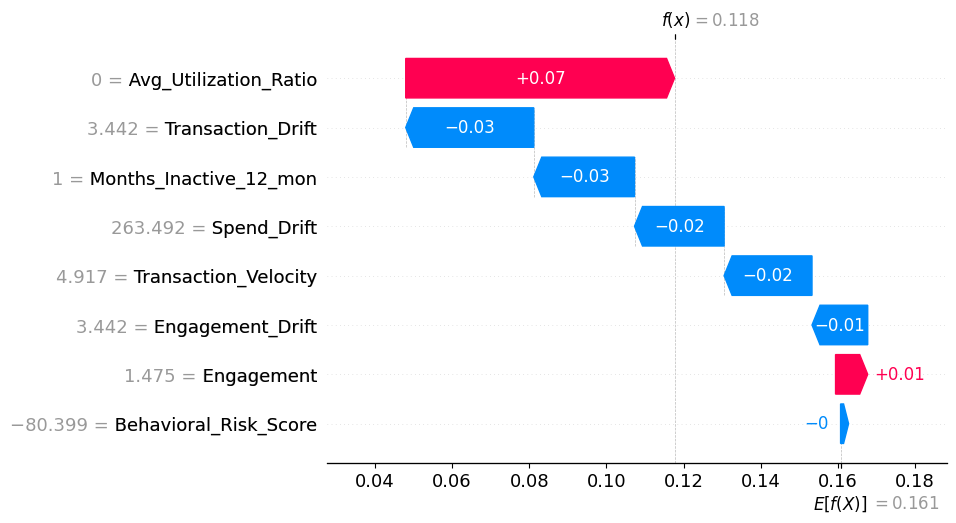

In [37]:
i = 10
shap.plots.waterfall(
    shap.Explanation(
        values=shap_to_plot[i],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[i],
        feature_names=X_test.columns
    )
)

This specific customer is predicted to churn because:
- Transaction drift is negative
- Inactivity is high
- Engagement is low

The waterfall plot shows how each feature contributes to the final churn prediction.

Negative transaction drift and high inactivity push the prediction toward churn,
while engagement and utilization may counterbalance the risk.

# Dependence Plot

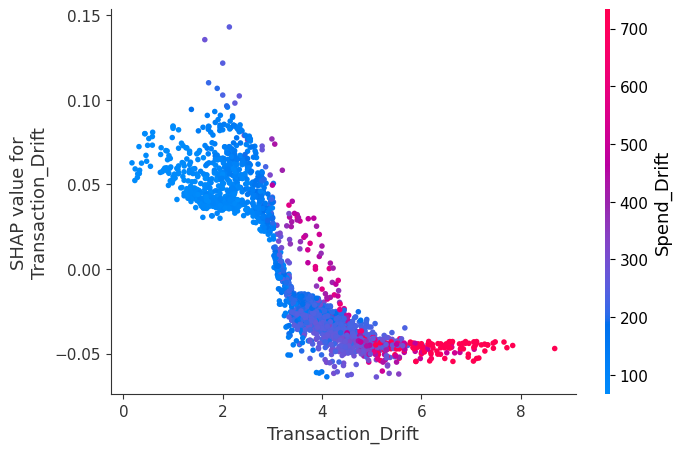

In [38]:
shap.dependence_plot(
    "Transaction_Drift",
    shap_to_plot,
    X_test
)

As Transaction Drift decreases → churn probability increases sharply

# Interaction Insight

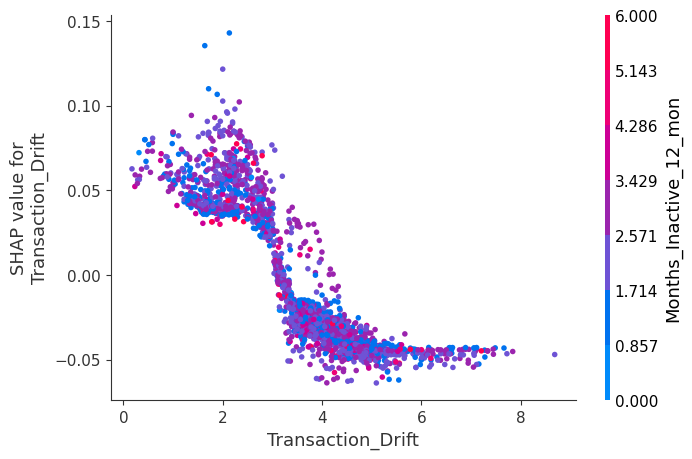

In [39]:
shap.dependence_plot(
    "Transaction_Drift",
    shap_to_plot,
    X_test,
    interaction_index="Months_Inactive_12_mon"
)

Drift + Inactivity together amplify churn risk

# SHAP Value Distribution

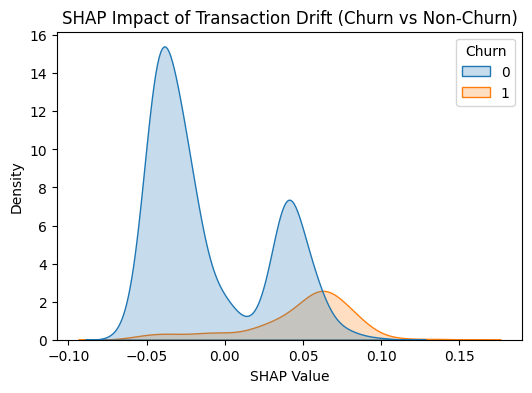

In [40]:
plt.figure(figsize=(6,4))
sns.kdeplot(
    x=shap_to_plot[:, features.index("Transaction_Drift")],
    hue=y_test,
    fill=True
)
plt.title("SHAP Impact of Transaction Drift (Churn vs Non-Churn)")
plt.xlabel("SHAP Value")
plt.show()

For churned users, Transaction Drift contributes strongly toward churn prediction,
while for non-churn users, its impact is minimal or opposite.

# Top Features Impact Distribution

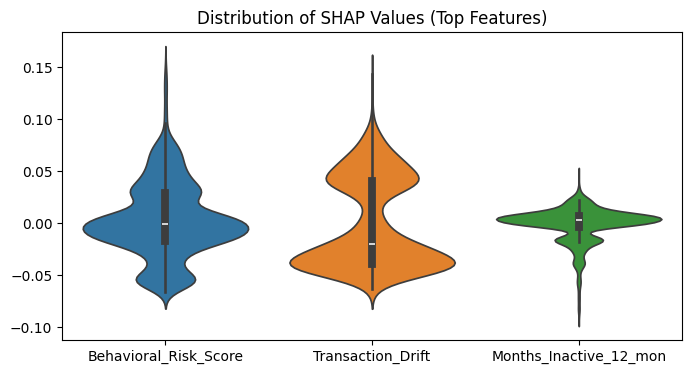

In [41]:
top_features = ["Behavioral_Risk_Score", "Transaction_Drift", "Months_Inactive_12_mon"]

shap_df = pd.DataFrame(shap_to_plot, columns=features)

plt.figure(figsize=(8,4))
sns.violinplot(data=shap_df[top_features])
plt.title("Distribution of SHAP Values (Top Features)")
plt.show()

Behavioral_Risk_Score shows the widest spread, indicating strong variability
in how different users exhibit churn behavior.

# Prediction Probability vs Drift

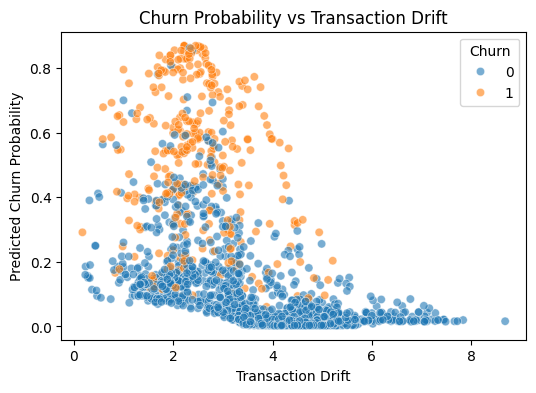

In [42]:
y_prob = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6,4))
sns.scatterplot(
    x=X_test["Transaction_Drift"],
    y=y_prob,
    hue=y_test,
    alpha=0.6
)
plt.title("Churn Probability vs Transaction Drift")
plt.xlabel("Transaction Drift")
plt.ylabel("Predicted Churn Probability")
plt.show()

As Transaction Drift becomes more negative, churn probability increases sharply.

# Risk Segmentation Plot

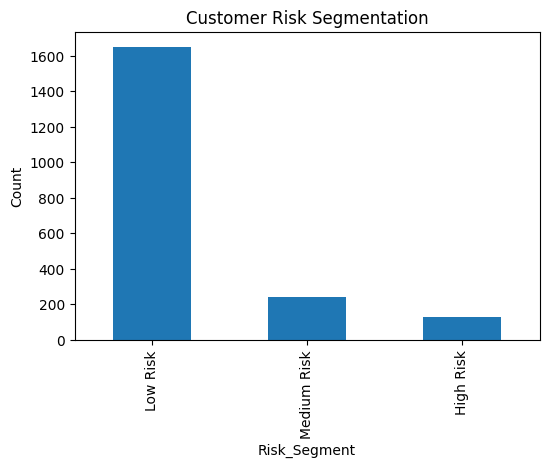

In [43]:
df_test = X_test.copy()
df_test["Churn_Prob"] = y_prob

df_test["Risk_Segment"] = pd.cut(
    df_test["Churn_Prob"],
    bins=[0, 0.3, 0.6, 1],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_counts = df_test["Risk_Segment"].value_counts()

risk_counts.plot(kind="bar", figsize=(6,4))
plt.title("Customer Risk Segmentation")
plt.ylabel("Count")
plt.show()

Customers can be segmented into actionable groups,
enabling targeted retention strategies.

# SHAP Interaction Heatmap

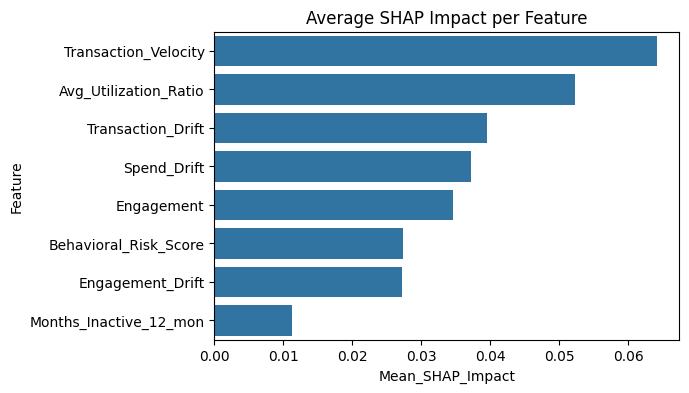

In [44]:
shap_interaction = np.abs(shap_to_plot).mean(axis=0)

interaction_df = pd.DataFrame({
    "Feature": features,
    "Mean_SHAP_Impact": shap_interaction
}).sort_values(by="Mean_SHAP_Impact", ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(data=interaction_df, x="Mean_SHAP_Impact", y="Feature")
plt.title("Average SHAP Impact per Feature")
plt.show()

Transaction Drift and Behavioral Risk Score dominate model decisions,
validating behavioral decay hypothesis.

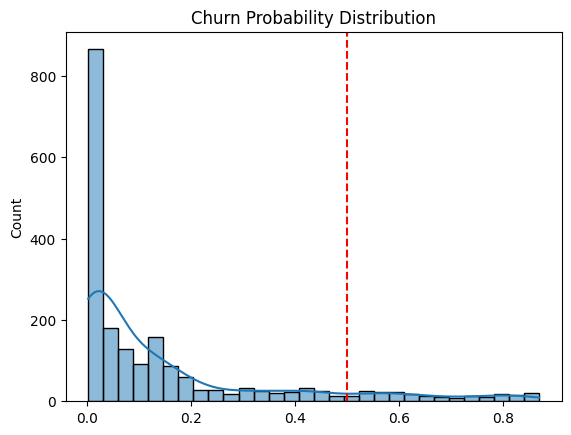

In [45]:
sns.histplot(y_prob, bins=30, kde=True)
plt.axvline(0.5, color='red', linestyle='--')
plt.title("Churn Probability Distribution")
plt.show()

In [47]:
import joblib

joblib.dump(rf_model, r"../dashboard/model.pkl")

['../dashboard/model.pkl']